In [1]:
from transformers import BitsAndBytesConfig, AutoModelForSeq2SeqLM, AutoTokenizer
from peft import PeftModel
import torch


In [14]:
base_model_name = "sagawa/ReactionT5v2-forward-USPTO_MIT"
lora_adapter_path = r"c:\Users\Happy\SRP\SRP Project MT training\models\reactiont5lora50rows2000steps_adapter_2000steps"

tokenizer = AutoTokenizer.from_pretrained(base_model_name)

auto_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_name, dtype=torch.float32)
model = PeftModel.from_pretrained(auto_model, lora_adapter_path)
model = model.merge_and_unload()
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [15]:
def format_reactiont5_input(reaction_smiles):
    if not isinstance(reaction_smiles, str) or ">" not in reaction_smiles:
        return reaction_smiles

    parts = reaction_smiles.split(">")
    if len(parts) < 2:
        return reaction_smiles

    reactants = parts[0]
    reagents = parts[1]
    return f"REACTANT:{reactants}REAGENT:{reagents}"


def inference_fp32(tokenizer, text, model, num_return_sequences=1, num_beams=10):
    device = next(model.parameters()).device
    inputs = tokenizer(text, return_tensors="pt", return_token_type_ids=False).to(device)
    outputs = model.generate(
        **inputs,
        max_length=256,
        repetition_penalty=1.0,
        do_sample=False,
        num_return_sequences=num_return_sequences,
        num_beams=num_beams,
        output_scores=True,
        return_dict_in_generate=True,
    )

    preds_fp32 = tokenizer.batch_decode(outputs.sequences, skip_special_tokens=True)
    return preds_fp32


In [16]:
from rdkit import Chem
from rdkit.Chem import Draw

In [17]:
text = "OB(O)c1ccc(C(F)(F)F)cc1.CCOC(=O)c1ccccc1S(N)(=O)=O>CC(=O)[O-].CC(=O)[O-].[Cu+2].Cc1cccc(C)n1.ClCCCl,CCOC(=O)c1ccccc1S(=O)(=O)Nc1ccc(C(F)(F)F)cc1>CCOC(=O)c1ccccc1S(=O)(=O)N(c1ccc(C(F)(F)F)cc1)c1ccc(C(F)(F)F)cc1"
text_list = text.split(",")

inp = text_list[0]
ground_truth = text_list[1]

inp, ground_truth

('OB(O)c1ccc(C(F)(F)F)cc1.CCOC(=O)c1ccccc1S(N)(=O)=O>CC(=O)[O-].CC(=O)[O-].[Cu+2].Cc1cccc(C)n1.ClCCCl',
 'CCOC(=O)c1ccccc1S(=O)(=O)Nc1ccc(C(F)(F)F)cc1>CCOC(=O)c1ccccc1S(=O)(=O)N(c1ccc(C(F)(F)F)cc1)c1ccc(C(F)(F)F)cc1')

Reactants

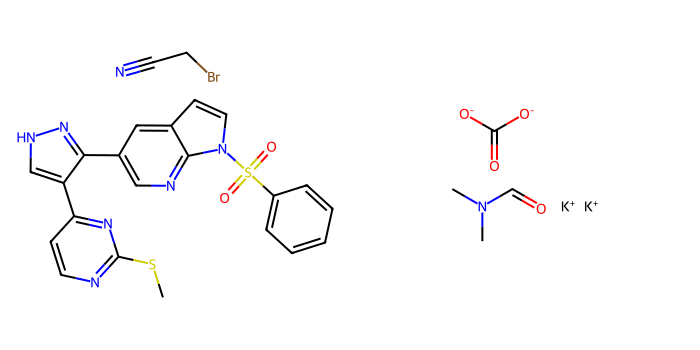

In [18]:
mol_inps = reaction_smiles.split(">")
mols = [Chem.MolFromSmiles(s) for s in mol_inps]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(350, 350)
)
img


Products ground truth

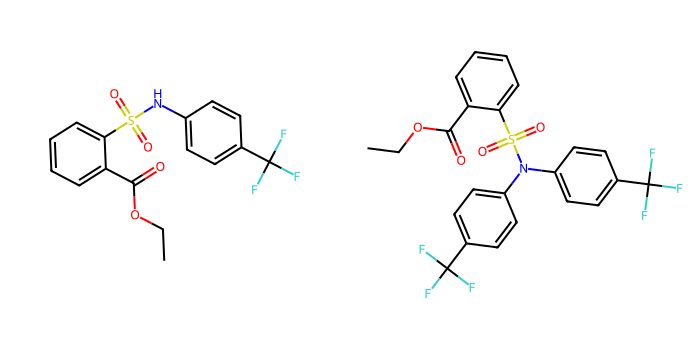

In [19]:
mol_ground_truths = ground_truth.split(">")
mols = [Chem.MolFromSmiles(s) for s in mol_ground_truths]

img = Draw.MolsToGridImage(
    mols, 
    molsPerRow=2,
    subImgSize=(350,350)
)
img

Predictions

In [20]:
reaction_smiles = "CSc1nccc(-c2c[nH]nc2-c2cnc3c(ccn3S(=O)(=O)c3ccccc3)c2)n1.N#CCBr>CN(C)C=O.O=C([O-])[O-].[K+].[K+]"
inp = format_reactiont5_input(reaction_smiles)


['CSc1nccc(-c2cn(CC#N)nc2-c2cnc3c(ccn3S(=O)(=O)c3ccccc3)c2)n1', 'CSc1nccc(-c2cnn(CC#N)c2-c2cnc3c(ccn3S(=O)(=O)c3ccccc3)c2)n1', 'CSc1nccc(-c2ccc(-c3cn(CC#N)nc3-c3cnc4c(ccn4S(=O)(=O)c4ccccc4)c3)nc2)n1', 'CSc1nccc(-c2nn(CC#N)cc2-c2cnc3c(ccn3S(=O)(=O)c3ccccc3)c2)n1', 'CSc1nccc(-c2cccc(-c3cn(CC#N)nc3-c3cnc4c(ccn4S(=O)(=O)c4ccccc4)c3)n2)n1', 'CSc1nccc(-c2ccc(-c3cn(CC#N)nc3-c3cnc4c(ccn4S(=O)(=O)c4ccccc4)c3)n2)n1', 'CSc1nccc(-c2n[nH]cc2-c2cnc3c(ccn3S(=O)(=O)c3ccccc3)c2)n1', 'CSc1nccc(-c2cccnc2-c2cnc3c(ccn3S(=O)(=O)c3ccccc3)c2)n1', 'CSc1nccc(-c2nn(CC#N)nc2-c2cnc3c(ccn3S(=O)(=O)c3ccccc3)c2)n1', 'CSc1nccc(-c2[nH]ncc2-c2cnc3c(ccn3S(=O)(=O)c3ccccc3)c2)n1']


[18:48:20] Can't kekulize mol.  Unkekulized atoms: 7 8 9 10 37


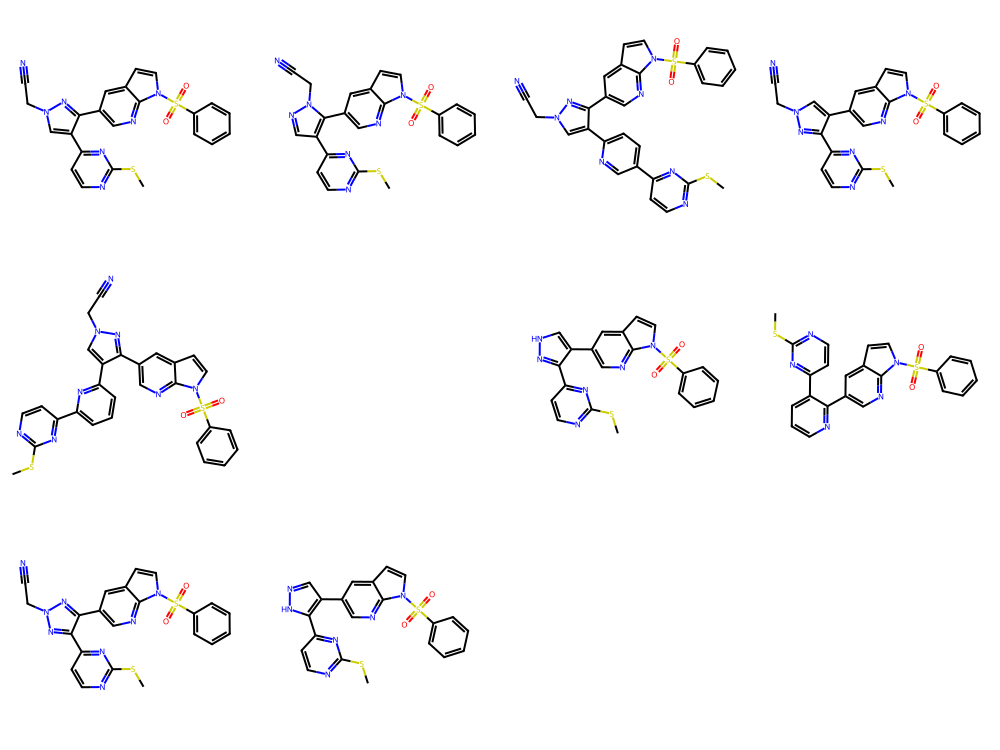

In [21]:
mol_fp32 = inference_fp32(tokenizer, inp, model, num_return_sequences=10, num_beams=10)

print(mol_fp32)

smiles = mol_fp32
mols = [Chem.MolFromSmiles(s) for s in smiles]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(250,250)
)
img


OLD

In [ ]:
# def inference_4bit(tokenizer, text, model_name, num_return_sequences=1, num_beams=10):
#     bnb_config = BitsAndBytesConfig(
#         load_in_4bit=True,
#         bnb_4bit_use_double_quant=True,
#         bnb_4bit_quant_type="nf4",
#         bnb_4bit_compute_dtype="float16",
#     )

#     model_4bit = AutoModelForSeq2SeqLM.from_pretrained(
#         model_name,
#         quantization_config=bnb_config,
#         device_map="auto",
#     ).to("cuda")

#     inputs = tokenizer(text, return_tensors="pt", return_token_type_ids=False).to(model_4bit.device)
#     outputs = model_4bit.generate(
#         **inputs, 
#         max_length=256, 
#         repetition_penalty=1.0, 
#         do_sample=False, 
#         num_return_sequences=num_return_sequences, 
#         num_beams=num_beams, 
#         output_scores=True, 
#         return_dict_in_generate=True
#     )

#     preds_4bit = tokenizer.batch_decode(outputs.sequences, skip_special_tokens=True)
#     return preds_4bit[0]

# def inference_8bit(tokenizer, text, model_name, num_return_sequences=1, num_beams=10):
#     bnb_config = BitsAndBytesConfig(
#         load_in_8bit=True,
#     )

#     model_8bit = AutoModelForSeq2SeqLM.from_pretrained(
#         model_name,
#         quantization_config=bnb_config,
#         device_map="auto",
#     )

#     inputs = tokenizer(text, return_tensors="pt", return_token_type_ids=False).to(model_8bit.device)
#     outputs = model_8bit.generate(
#         **inputs, 
#         max_length=256, 
#         repetition_penalty=1.0, 
#         do_sample=False, 
#         num_return_sequences=num_return_sequences, 
#         num_beams=num_beams, 
#         output_scores=True, 
#         return_dict_in_generate=True
#     )

#     preds_8bit = tokenizer.batch_decode(outputs.sequences, skip_special_tokens=True)
#     return preds_8bit[0]

# def inference_fp16(tokenizer, text, model_name, num_return_sequences=1, num_beams=10):
#     model_fp16 = AutoModelForSeq2SeqLM.from_pretrained(
#         model_name,
#         torch_dtype=torch.float16,
#         device_map="auto",
#     ).to("cuda")

#     inputs = tokenizer(text, return_tensors="pt", return_token_type_ids=False).to(model_fp16.device)
#     outputs = model_fp16.generate(
#         **inputs, 
#         max_length=256, 
#         repetition_penalty=1.0, 
#         do_sample=False, 
#         num_return_sequences=num_return_sequences, 
#         num_beams=num_beams, 
#         output_scores=True, 
#         return_dict_in_generate=True
#     )

#     preds_fp16 = tokenizer.batch_decode(outputs.sequences, skip_special_tokens=True)
#     return preds_fp16[0]